In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os
import utils

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [14]:
query_min = "SELECT * FROM gold.active_1min"
query_30 = "SELECT * FROM gold.active_30min"
query_day = "SELECT * FROM gold.active_daily"

In [15]:
df_min = pd.read_sql(query_min,engine)
df_30 = pd.read_sql(query_30,engine)
df_day = pd.read_sql(query_day,engine)

Daily Volume Analysis

In [5]:
df_day = utils.add_winsorized_col(df_day,'volume')

In [6]:
utils.descriptive_analysis(df_day,'volume')

count    2.290000e+02
mean     1.143470e+06
std      3.932360e+05
min      1.745000e+04
25%      8.909590e+05
50%      1.046006e+06
75%      1.320783e+06
max      2.635138e+06
Name: volume, dtype: float64

Median:  1046006.0
Std Dev:  393235.9633787837
IQR:  429824.0


In [8]:
utils.descriptive_analysis(df_day,'volume_winsorized')

count    2.290000e+02
mean     1.144968e+06
std      3.802364e+05
min      5.276012e+05
25%      8.909590e+05
50%      1.046006e+06
75%      1.320783e+06
max      2.367908e+06
Name: volume_winsorized, dtype: float64

Median:  1046006.0
Std Dev:  380236.3759154156
IQR:  429824.0


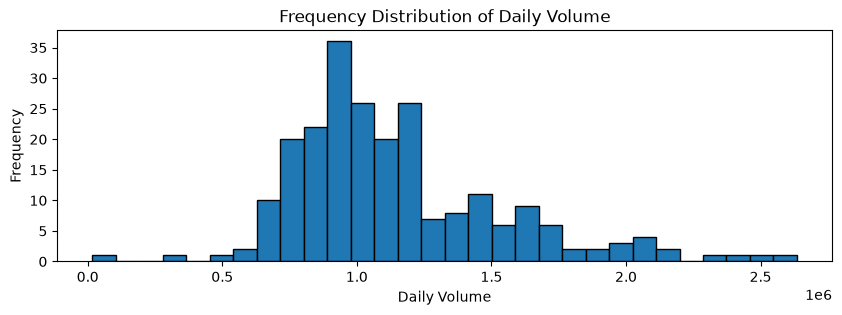

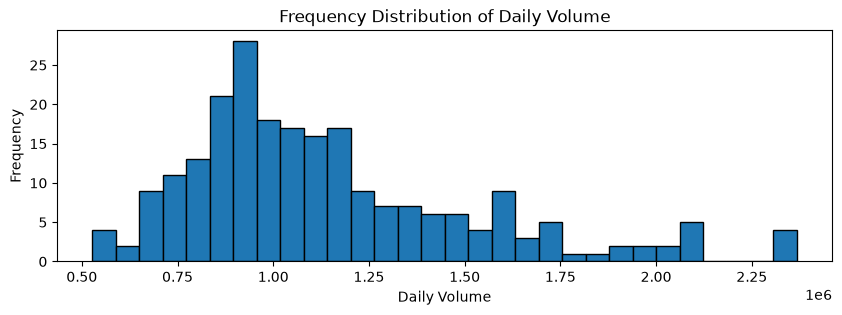

In [9]:
utils.frequency_hist(df_day,'volume',30,'Daily Volume')
utils.frequency_hist(df_day,'volume_winsorized',30,'Daily Volume')

30 Min Bucket Volume Analysis

In [10]:
df_30 = utils.add_winsorized_col(df_30,'volume')

agg_30_volume = utils.descriptive_groupby(df_30,'bar_time','volume')
agg_30_volume_win = utils.descriptive_groupby(df_30,'bar_time','volume_winsorized')

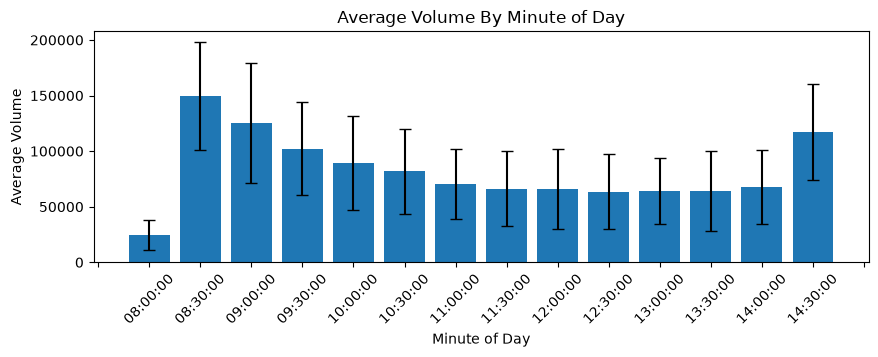

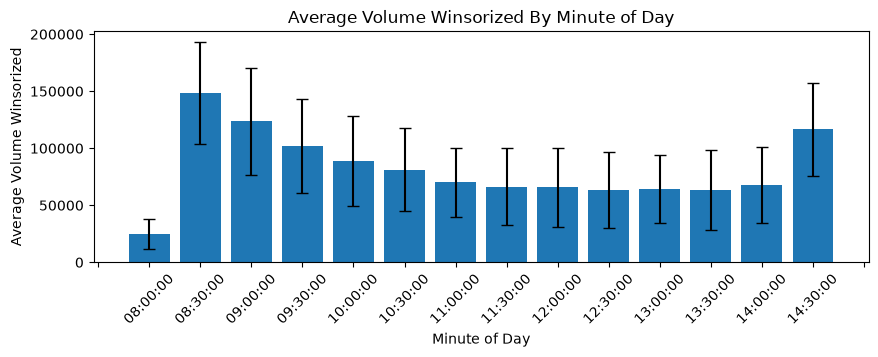

In [11]:
utils.bar_chart(agg_30_volume,'mean','Minute of Day','Average Volume',tickbin=16,yerror=agg_30_volume['std'])
utils.bar_chart(agg_30_volume_win,'mean','Minute of Day','Average Volume Winsorized',tickbin=16,yerror=agg_30_volume_win['std'])

In [17]:
df_min = utils.add_winsorized_col(df_min,'volume')

agg_min_volume = utils.descriptive_groupby(df_min,'bar_time','volume')
agg_min_volume_win = utils.descriptive_groupby(df_min,'bar_time','volume_winsorized')

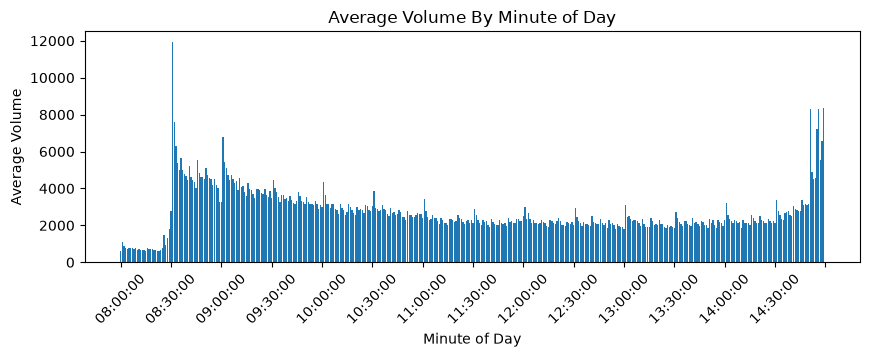

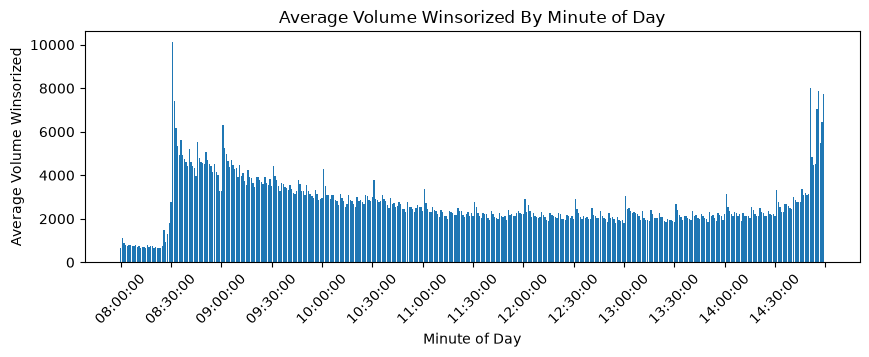

In [18]:
utils.bar_chart(agg_min_volume,'mean','Minute of Day','Average Volume',tickbin=16)
utils.bar_chart(agg_min_volume_win,'mean','Minute of Day','Average Volume Winsorized',tickbin=16)